# Notes

Had issues running via GPU. Got odd "CUDA_ERROR_INVALID_HANDLE" error during training which could not be resolved. Using CPU seems to work but the concern was performance. 

In [14]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# import tensorflow as tf
# tf.keras.backend.clear_session()

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[]


Taken from https://github.com/davidADSP/Generative_Deep_Learning_2nd_Edition/blob/main/notebooks/02_deeplearning/01_mlp/mlp.ipynb

# Utils

In [3]:
import matplotlib.pyplot as plt


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()


# 👀 Multilayer perceptron (MLP)

In this notebook, we'll walk through the steps required to train your own multilayer perceptron on the CIFAR dataset

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, optimizers, utils, datasets
# from .utils import display

## 0. Parameters <a name="parameters"></a>

In [5]:
NUM_CLASSES = 10

## 1. Prepare the Data <a name="prepare"></a>

## Original (slow & skipped)

In [6]:
# (x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

In [7]:
# x_train = x_train.astype("float32") / 255.0
# x_test = x_test.astype("float32") / 255.0

# y_train = utils.to_categorical(y_train, NUM_CLASSES)
# y_test = utils.to_categorical(y_test, NUM_CLASSES)

## From Google Drive (works)

Problem: downloading the full dataset was very slow and resource wasting so decided to use Google drive as cache to save a ton of time and resources. The files are 100MB so not too bad. The code below was mostly generated by GPT-5.3-Codex with minor tweaks. 

In [8]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from tensorflow.keras import utils

# NUM_CLASSES = 10

# Update this folder to where your CSVs are in Drive
data_dir = "/content/drive/MyDrive/Colab Data"

train_df = pd.read_csv(f"{data_dir}/cifar10_train.csv")
test_df  = pd.read_csv(f"{data_dir}/cifar10_test.csv")


Mounted at /content/drive


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 3073 entries, pixel_0 to label
dtypes: int64(3073)
memory usage: 1.1 GB


In [10]:
train_df.describe()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_3063,pixel_3064,pixel_3065,pixel_3066,pixel_3067,pixel_3068,pixel_3069,pixel_3070,pixel_3071,label
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,130.710740,130.14036,131.050440,131.568860,132.184700,132.851840,133.371540,133.890920,134.485040,134.93260,...,113.716260,113.735320,113.778520,113.813200,113.864120,113.877800,113.830580,113.906240,114.381860,4.50000
std,73.412873,72.44259,72.240546,72.016555,71.714551,71.537505,71.353558,71.281237,71.071698,71.03647,...,64.345623,64.431996,64.401897,64.502684,64.511269,64.738943,64.894603,65.212671,66.077526,2.87231
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,71.000000,71.00000,73.000000,73.000000,75.000000,75.000000,76.000000,76.750000,78.000000,78.00000,...,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,63.000000,2.00000
50%,128.000000,127.00000,129.000000,130.000000,130.000000,131.000000,132.000000,132.000000,133.000000,134.00000,...,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,4.50000
75%,189.000000,188.00000,188.000000,188.000000,189.000000,190.000000,190.000000,191.000000,191.000000,192.00000,...,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,158.000000,7.00000
max,255.000000,255.00000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,9.00000


In [40]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 3073 entries, pixel_0 to label
dtypes: int64(3073)
memory usage: 234.5 MB


In [11]:

# Accept common label column names
possible_label_cols = ["label", "labels", "target", "y", "class"]
label_col = next((c for c in possible_label_cols if c in train_df.columns), train_df.columns[0])

y_train_raw = train_df[label_col].to_numpy()
y_test_raw  = test_df[label_col].to_numpy()

X_train = train_df.drop(columns=[label_col]).to_numpy(dtype=np.float32)
X_test  = test_df.drop(columns=[label_col]).to_numpy(dtype=np.float32)

# Scale to [0,1]
if X_train.max() > 1.0:
    X_train /= 255.0
    X_test  /= 255.0

# CIFAR-10 flattened is 3072 = 32*32*3
# Common CSV layout is channel-first blocks: R(1024), G(1024), B(1024)
x_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_test  = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

y_train = utils.to_categorical(y_train_raw, NUM_CLASSES)
y_test  = utils.to_categorical(y_test_raw, NUM_CLASSES)

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape, "y_test :", y_test.shape)

x_train: (50000, 32, 32, 3) y_train: (50000, 10)
x_test : (10000, 32, 32, 3) y_test : (10000, 10)


In [12]:
import tensorflow as tf
# tf.keras.backend.clear_session()

# Ensure clean dtypes
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

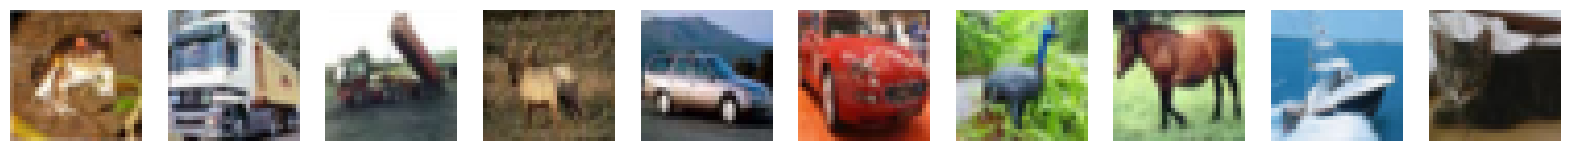

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [13]:
display(x_train[:10])
print(y_train[:10])

## 2. Build the model <a name="build"></a>

In [14]:
input_layer = layers.Input((32, 32, 3))

x = layers.Flatten()(input_layer)
x = layers.Dense(200, activation="relu")(x)
x = layers.Dense(150, activation="relu")(x)

output_layer = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(input_layer, output_layer)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       614,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,260 (2.47 MB)

 Trainable params: 646,260 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the model <a name="train"></a>

In [15]:
opt = optimizers.Adam(learning_rate=0.0005)
model.compile(
    loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"]
)

In [16]:
model.fit(x_train, y_train, batch_size=32, epochs=10, shuffle=True)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.3298 - loss: 1.8533
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.3995 - loss: 1.6776
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4295 - loss: 1.5982
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4493 - loss: 1.5434
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.4631 - loss: 1.4994
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4750 - loss: 1.4733
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.4849 - loss: 1.4429
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.4917 - loss: 1.4193
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5047 - loss: 1.3952
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.5093 - loss: 1.3766


## 4. Evaluation <a name="evaluate"></a>

In [17]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4846 - loss: 1.4500


[1.4500229358673096, 0.4846000075340271]

In [18]:
CLASSES = np.array(
    [
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
    ]
)

preds = model.predict(x_test)
preds_single = CLASSES[np.argmax(preds, axis=-1)]
actual_single = CLASSES[np.argmax(y_test, axis=-1)]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


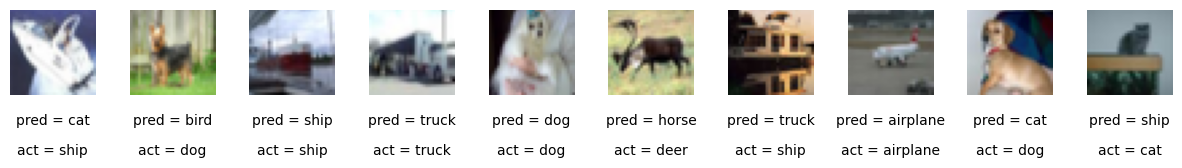

In [25]:
n_to_show = 10
indices = np.random.choice(range(len(x_test)), n_to_show)

fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, idx in enumerate(indices):
    img = x_test[idx]
    ax = fig.add_subplot(1, n_to_show, i + 1)
    ax.axis("off")
    ax.text(
        0.5,
        -0.35,
        "pred = " + str(preds_single[idx]),
        fontsize=10,
        ha="center",
        transform=ax.transAxes,
    )
    ax.text(
        0.5,
        -0.7,
        "act = " + str(actual_single[idx]),
        fontsize=10,
        ha="center",
        transform=ax.transAxes,
    )
    ax.imshow(img)

# Multi-Activator Function Training/Evaluation

In [26]:
def build_mlp(activation_name, num_classes=10):
  inp = layers.Input((32, 32, 3))
  x = layers.Flatten()(inp)
  if activation_name == "leakyrelu":
    x = layers.Dense(200)(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dense(150)(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
  else:
    x = layers.Dense(200, activation=activation_name)(x)
    x = layers.Dense(150, activation=activation_name)(x)
  
  out = layers.Dense(num_classes, activation="softmax")(x)
  return models.Model(inp, out)

In [27]:
activations = ["relu", "leakyrelu", "sigmoid"]
results = {}
histories = {}
trained_models = {}

In [28]:
for act in activations:
  tf.keras.backend.clear_session() # ensures fresh graph/weights each run
  model = build_mlp(act, NUM_CLASSES)
  model.compile(
      optimizer=optimizers.Adam(learning_rate=0.0005),
      loss="categorical_crossentropy",
      metrics=["accuracy"],
  )

  trained_models[act] = model
  
  print(f"\nTraining with {act} ...")
  history = model.fit(
      x_train, y_train,
      batch_size=32,
      epochs=10,
      shuffle=True,
      validation_data=(x_test, y_test),
      verbose=1
  )

  histories[act] = history.history
  
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
  results[act] = {"test_loss": test_loss, "test_acc": test_acc}


Training with relu ...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.3381 - loss: 1.8433 - val_accuracy: 0.3905 - val_loss: 1.7023
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4089 - loss: 1.6562 - val_accuracy: 0.4275 - val_loss: 1.6190
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4363 - loss: 1.5753 - val_accuracy: 0.4606 - val_loss: 1.5245
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.4559 - loss: 1.5237 - val_accuracy: 0.4443 - val_loss: 1.5533
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4684 - loss: 1.4915 - val_accuracy: 0.4678 - val_loss: 1.5003
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4765 - loss: 1.4671 - val_accuracy: 0.4600 - val_loss: 1.5195
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4858 - loss: 1.4450 - val_accuracy: 0.4829 - val_loss: 1.4461
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/s

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



Training with leakyrelu ...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3310 - loss: 1.8509 - val_accuracy: 0.3881 - val_loss: 1.7106
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.3992 - loss: 1.6785 - val_accuracy: 0.4132 - val_loss: 1.6733
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4281 - loss: 1.5998 - val_accuracy: 0.4314 - val_loss: 1.5975
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4492 - loss: 1.5454 - val_accuracy: 0.4494 - val_loss: 1.5465
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4628 - loss: 1.5057 - val_accuracy: 0.4713 - val_loss: 1.4913
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4778 - loss: 1.4675 - val_accuracy: 0.4675 - val_loss: 1.5044
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4904 - loss: 1.4279 - val_accuracy: 0.4740 - val_loss: 1.4663
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 1

In [29]:
print("\nFinal comparison:")
for act, r in results.items():
  print(act, "->", r)


Final comparison:
relu -> {'test_loss': 1.4376963376998901, 'test_acc': 0.49410000443458557}
leakyrelu -> {'test_loss': 1.420106053352356, 'test_acc': 0.5015000104904175}
sigmoid -> {'test_loss': 1.5059089660644531, 'test_acc': 0.46459999680519104}


In [30]:
# 1) Table-style comparison
import pandas as pd

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values("test_acc", ascending=False)
comparison_df

,test_loss,test_acc
leakyrelu,1.420106,0.5015
relu,1.437696,0.4941
sigmoid,1.505909,0.4646


## Plot Accuracy Comparison

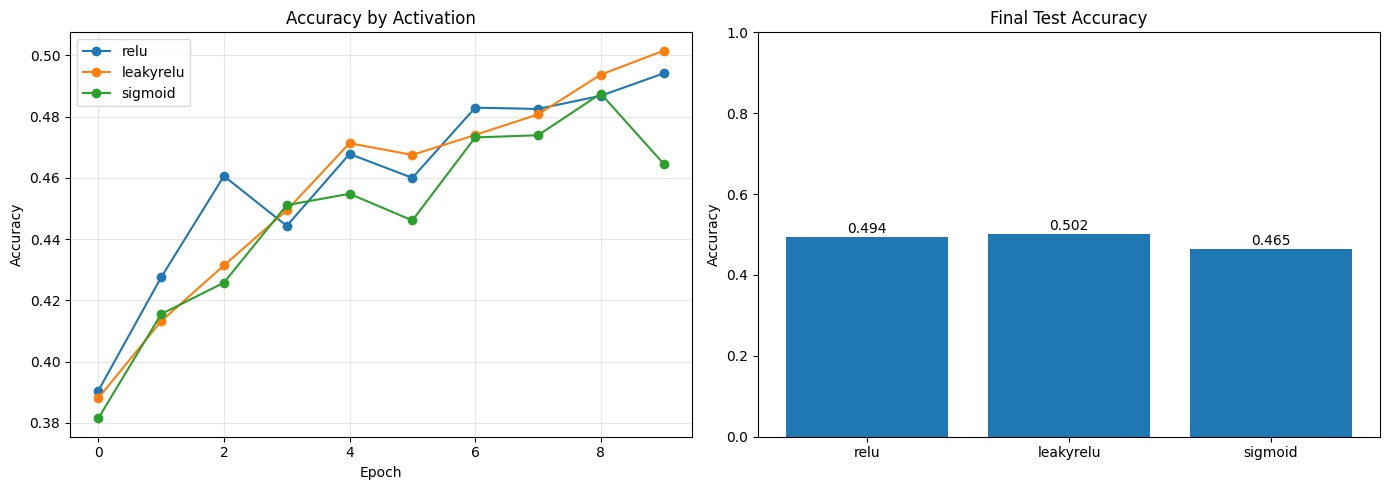

In [31]:
# 2) Plot validation accuracy curves + final test accuracy bar chart
# import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: validation accuracy over epochs
for act, h in histories.items():
    # fallback to training accuracy if val_accuracy wasn't recorded
    y = h["val_accuracy"] if "val_accuracy" in h else h["accuracy"]
    axes[0].plot(y, marker="o", label=act)

axes[0].set_title("Accuracy by Activation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: final test accuracy
acts = list(results.keys())
accs = [results[a]["test_acc"] for a in acts]
axes[1].bar(acts, accs)
axes[1].set_title("Final Test Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)

for i, v in enumerate(accs):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

## Confusion-Matrix Comparison

In [33]:
best_act = max(results, key=lambda k: results[k]["test_acc"])
best_model = trained_models[best_act]

print("Best activation:", best_act)
print("Best test accuracy:", results[best_act]["test_acc"])


Best activation: leakyrelu
Best test accuracy: 0.5015000104904175


In [34]:
y_pred_prob = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

In [35]:
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=NUM_CLASSES).numpy()

In [36]:
cm_norm = cm.astype("float32") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

In [37]:
if "CLASSES" in globals():
  labels = CLASSES
else:
  labels = np.array([str(i) for i in range(NUM_CLASSES)])

[Text(0, 0, 'airplane'),
 Text(0, 1, 'automobile'),
 Text(0, 2, 'bird'),
 Text(0, 3, 'cat'),
 Text(0, 4, 'deer'),
 Text(0, 5, 'dog'),
 Text(0, 6, 'frog'),
 Text(0, 7, 'horse'),
 Text(0, 8, 'ship'),
 Text(0, 9, 'truck')]

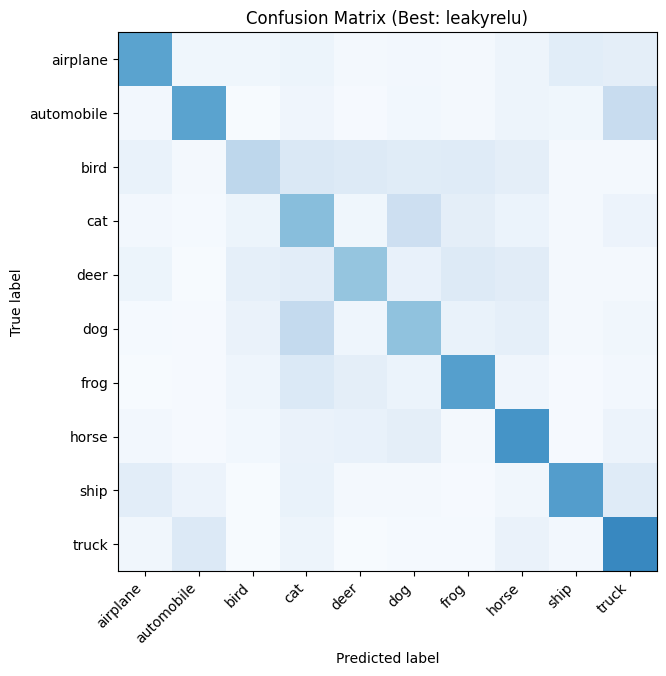

In [38]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_title(f"Confusion Matrix (Best: {best_act})")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

In [39]:
for i in range(NUM_CLASSES):
  for j in range(NUM_CLASSES):
    v = cm_norm[i, j]
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Row-normalized")
    plt.tight_layout()
    plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>